# Data anlysis of MQ dev results 


In [91]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from upsetplot import UpSet
from matplotlib_venn import venn2
from matplotlib_venn import venn3

import re
from collections import Counter

plt.rcParams["font.family"] = "Arial" 

import biotite.database.entrez as entrez
import biotite.sequence as seq
from biotite.sequence import ProteinSequence
import biotite.sequence.io.fasta as fasta

import mpl_scatter_density 
from matplotlib.colors import LinearSegmentedColormap
from mpl_scatter_density import ScatterDensityArtist
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import scipy.stats as stats
from statannotations.Annotator import Annotator

from scipy.stats import gaussian_kde

%load_ext autoreload
from protein_inference import * 
from extracting_sequences import *

from collections import defaultdict, Counter


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
color_map = {
    '0': '#ffbc42',
    'VM': '#ffbc42',
    'SBM 0': '#ffbc42',
    'sbm_o_4': '#2ca02c', 
    'st':    '#d81159', 
    'Standard':    '#d81159', 
    'Unique Standard':    '#d81159',
    'sbm_3': '#73d2de', 
    'SBM 3': '#73d2de', 
    'MQ SBM 3': '#73d2de', 
    'MQ SBM 3 Percolator': '#b7e8ee', 
    'sbm3': '#73d2de',
    'Unique SBM 3': '#73d2de',
    'sbm_8': '#218380',
    'sbm8': '#218380',
    'SBM 8': '#218380', 
    'MSFragger': '#60435f', 
    'MSFragger 9nl Percolator': '#60435f', 
    'Unique MSFragger': '#60435f'
}

custom_order = ['VM', 'Standard', 'SBM 3', 'SBM 8']

# Importing the data

In [3]:
fig_dir = 'mq_dev_analysis_figs/with_fdr'
root_dir = 'data/MQ_with_FDR'
exposure = 'exposure_sites/sites_exposure_w_FDR.txt'
f_path = 'data/HUMAN.fasta'

psm_file = 'run8/psm.tsv'
psm_file_percolator = 'run7/psm.tsv'

input_file_smb3 = 'SBM 3/msms.txt'

per_path3 = 'sbm3/percolator.target.psms.txt'
per_path3_wmbr = 'sbm3_wmbr/percolator.target.psms.txt'
per_path3_wmbr_secpep = 'sbm3_wmbr_secpep/percolator.target.psms.txt'
per_path3_wsecpep = 'sbm3_secpep/percolator.target.psms.txt'
per_path8 = 'sbm8/percolator.target.psms.txt'
per_pathst = 'st/percolator.target.psms.txt'

msfragger_folder_path = 'data/msfragger_runs'

big_df_folder_path = 'MQ_with_FDR/output.tsv'


# Preprocessing



In [51]:
big_df = pd.read_csv(big_df_folder_path, delimiter="\t")

big_df

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/1882084170.py:1: DtypeWarning: Columns (68,77,78,79,80,81,82,83,99,116,117) have mixed types. Specify dtype option on import or set low_memory=False.
  big_df = pd.read_csv(big_df_folder_path, delimiter="\t")


,Raw file,Scan number,Scan index,Sequence,Length,Missed cleavages,Modifications,Modified sequence,Oxidation (M) Probabilities,SUMO2/3-DVFQQQTGG Probabilities,...,isoforms,uniprot_w_isoforms,isoform_seqs,k_positions,matched_sequences,extracted_sse,extracted_pddlt,all_matched_sequences_AF,all_surr_pddlt,matched_sequences_AF
0,20170315_QE4_LC12_IAH_SUMO_HEK_Heat_E1_F4_R1,21213,17304,AAAAAAGAGPEMVRGQVF,18,1,Acetyl (Protein N-term),_(Acetyl (Protein N-term))AAAAAAGAGPEMVRGQVF_,NaN,NaN,...,[],['P28482'],['MAAAAAAGAGPEMVRGQVFDVGPRYTNLSYIGEGAYGMVCSAYD...,"[48, 54, 55, 73, 99, 114, 117, 138, 151, 164, ...",[],[],[],['-------------MAAAAAAGAGPEMVRGQVFDVGPRYTNLSYI...,"[['-', '-', '-', '-', '-', '-', '-', '-', '-',...",[]
1,20170315_QE4_LC12_IAH_SUMO_HEK_Heat_E2_F3_R2,21250,17196,AAAAAAGAGPEMVRGQVF,18,1,Acetyl (Protein N-term),_(Acetyl (Protein N-term))AAAAAAGAGPEMVRGQVF_,NaN,NaN,...,[],['P28482'],['MAAAAAAGAGPEMVRGQVFDVGPRYTNLSYIGEGAYGMVCSAYD...,"[48, 54, 55, 73, 99, 114, 117, 138, 151, 164, ...",[],[],[],['-------------MAAAAAAGAGPEMVRGQVFDVGPRYTNLSYI...,"[['-', '-', '-', '-', '-', '-', '-', '-', '-',...",[]
2,20170315_QE4_LC12_IAH_SUMO_HEK_Heat_E2_F6_R1,27660,22505,AAAAAEQQQFYLLLGNLLSPDNVVRK,26,2,Acetyl (Protein N-term),_(Acetyl (Protein N-term))AAAAAEQQQFYLLLGNLLSP...,NaN,NaN,...,[],['O00410'],['MAAAAAEQQQFYLLLGNLLSPDNVVRKQAEETYENIPGQSKITF...,"[27, 41, 90, 107, 108, 134, 174, 212, 238, 249...",[],[],[],['----------------------------------MAAAAAEQQQ...,"[['-', '-', '-', '-', '-', '-', '-', '-', '-',...",[]
3,20170315_QE4_LC12_IAH_SUMO_HEK_Heat_E2_F6_R2,27635,22514,AAAAAEQQQFYLLLGNLLSPDNVVRK,26,2,Acetyl (Protein N-term),_(Acetyl (Protein N-term))AAAAAEQQQFYLLLGNLLSP...,NaN,NaN,...,[],['O00410'],['MAAAAAEQQQFYLLLGNLLSPDNVVRKQAEETYENIPGQSKITF...,"[27, 41, 90, 107, 108, 134, 174, 212, 238, 249...",[],[],[],['----------------------------------MAAAAAEQQQ...,"[['-', '-', '-', '-', '-', '-', '-', '-', '-',...",[]
4,20170315_QE4_LC12_IAH_SUMO_HEK_Heat_E1_F1_R1,13483,10577,AAAAAMAEQ,9,1,Acetyl (Protein N-term),_(Acetyl (Protein N-term))AAAAAMAEQ_,NaN,NaN,...,[],['Q7L5D6'],['MAAAAAMAEQESARNGGRNRGGVQRVEGKLRASVEKGDYYEAHQ...,"[29, 36, 58, 95, 110, 131, 139, 155, 207, 209,...",[],[],[],['--------------------------------MAAAAAMAEQES...,"[['-', '-', '-', '-', '-', '-', '-', '-', '-',...",[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1764430,20170315_QE4_LC12_IAH_SUMO_HEK_Heat_E1_F5_R3,17254,13611,YYTPVPCESATAKAV,15,2,SBM_8_o_SUMO2/3-DVFQQQTGG,_YYTPVPCESATAK(su)AV_,NaN,YYTPVPCESATAK(1)AV,...,[],['P51692'],['MAVWIQAQQLQGEALHQMQALYGQHFPIEVRHYLSQWIESQAWD...,"[56, 70, 71, 84, 86, 140, 163, 164, 207, 232, ...",['DSQERMFWNLMPFTTRDFSIRSLADRLGDLNYLIYVFPDRPKDE...,"[['b', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c',...","[[79.75, 76.14, 69.95, 71.16, 74.74, 81.09, 87...",['-----MAVWIQAQQLQGEALHQMQALYGQHFPIEVRHYLSQWIE...,"[['-', '-', '-', '-', '-', 50.89, 70.1, 82.49,...",['DSQERMFWNLMPFTTRDFSIRSLADRLGDLNYLIYVFPDRPKDE...
1764431,20170315_QE4_LC12_IAH_SUMO_HEK_Heat_E2_F2_R3,20460,16463,YYTPVPCESATAKAV,15,2,SBM_8_o_SUMO2/3-DVFQQQTGG,_YYTPVPCESATAK(su)AV_,NaN,YYTPVPCESATAK(1)AV,...,[],['P51692'],['MAVWIQAQQLQGEALHQMQALYGQHFPIEVRHYLSQWIESQAWD...,"[56, 70, 71, 84, 86, 140, 163, 164, 207, 232, ...",['DSQERMFWNLMPFTTRDFSIRSLADRLGDLNYLIYVFPDRPKDE...,"[['b', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c',...","[[79.75, 76.14, 69.95, 71.16, 74.74, 81.09, 87...",['-----MAVWIQAQQLQGEALHQMQALYGQHFPIEVRHYLSQWIE...,"[['-', '-', '-', '-', '-', 50.89, 70.1, 82.49,...",['DSQERMFWNLMPFTTRDFSIRSLADRLGDLNYLIYVFPDRPKDE...
1764432,20170315_QE4_LC12_IAH_SUMO_HEK_Heat_E2_F3_R1,17190,13660,YYTPVPCESATAKAV,15,2,SBM_8_o_SUMO2/3-DVFQQQTGG,_YYTPVPCESATAK(su)AV_,NaN,YYTPVPCESATAK(1)AV,...,[],['P51692'],['MAVWIQAQQLQGEALHQMQALYGQHFPIEVRHYLSQWIESQAWD...,"[56, 70, 71, 84, 86, 140, 163, 164, 207, 232, ...",['DSQERMFWNLMPFTTRDFSIRSLADRLGDLNYLIYVFPDRPKDE...,"[['b', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c',...","[[79.75, 76.14, 69.95, 71.16, 74.74, 81.09, 87...",['-----MAVW

In [52]:
#big_df = big_df[big_df['PEP'] <= 0.05]
big_df = big_df[big_df['Contaminant'] != '+']
big_df['Reverse'].fillna('-', inplace=True)
big_df['Modified sequence'] = big_df['Modified sequence'].str.replace(r'st_o_SUMO2/3-DVFQQQTGG|ST_2_SUMO2/3-DVFQQQTGG|SBM_4_o_SUMO2/3-DVFQQQTGG|SBM_5_o_SUMO2/3-DVFQQQTGG|SBM_3_o_SUMO2/3-DVFQQQTGG|SBM_2_o_SUMO2/3-DVFQQQTGG|SBM_8_o_SUMO2/3-DVFQQQTGG|SBM_0_o_SUMO2/3-DVFQQQTGG', 'su', regex=True)
big_df["Modified sequence"] = big_df["Modified sequence"].str.replace(r'_', '', regex=True).str.replace(r'\(Acetyl \(Protein N-term\)\)', '', regex=True).str.replace(r'\(Oxidation \(M\)\)', '', regex=True)  
big_df['Masses'] = big_df['Masses'].astype(str)
big_df['Intensities'] = big_df['Intensities'].astype(str)
big_df['Matches'] = big_df['Matches'].astype(str)
big_df['Masses'] = big_df['Masses'].apply(lambda x: [float(val) for val in x.split(';')])
big_df['Intensities'] = big_df['Intensities'].apply(lambda x: [float(val) for val in x.split(';')])
big_df['Matches'] = big_df['Matches'].apply(lambda x: [val for val in x.split(';')])
big_df['Proteins'] = big_df['Proteins'].str.split(';')
big_df['Positions within proteins'] = big_df['Positions within proteins'].str.split(';')
big_df['Positions within proteins'] = big_df['Positions within proteins'].apply(
    lambda x: [int(pos) for pos in x if isinstance(x, list) and pos.strip().isdigit()] if isinstance(x, list) else []
)

In [53]:
# Extract E, F, and R values
big_df['E'] = big_df['Raw file'].str.extract(r'_E(\d+)')
big_df['F'] = big_df['Raw file'].str.extract(r'_F(\d+)')
big_df['R'] = big_df['Raw file'].str.extract(r'_R(\d+)')
big_df[['E', 'F', 'R']] = big_df[['E', 'F', 'R']].apply(pd.to_numeric)

In [55]:
# seperate sets 
no_fdr_set = big_df[big_df['Dataset'] == 'SBM 3 no FDR']
big_df = big_df[big_df['Dataset'] != 'SBM 3 no FDR']

all_reverse = big_df[big_df['Reverse'] != '-']
all_psms = big_df[big_df['Reverse'] != '+']
all_counts = all_psms.groupby('Dataset').size()

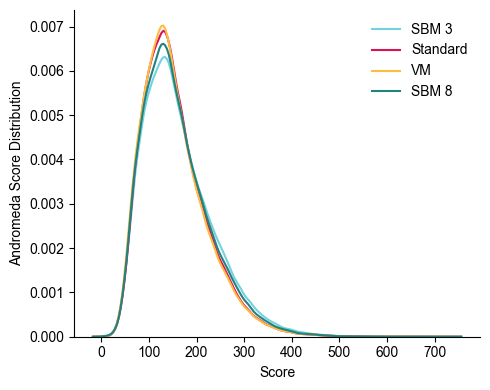

In [56]:
fig, ax = plt.subplots(figsize=(5, 4))
ax = None  # Initialize ax
for dataset in big_df['Dataset'].unique():
    ax = sns.kdeplot(
        data=big_df[big_df['Dataset'] == dataset], 
        x='Score', 
        color=color_map.get(dataset, 'grey'),  # Default to grey if not in color_map
        label=dataset, 
        common_norm=False, 
        fill=False
    )

# Customize plot aesthetics
if ax:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# Labels and title
plt.xlabel('Score')
plt.ylabel('Andromeda Score Distribution')
plt.title('')
plt.tight_layout()
legend = plt.legend(loc='upper right', frameon=True)
legend.get_frame().set_facecolor('white')  
legend.get_frame().set_alpha(1)
legend.get_frame().set_linewidth(0) 

file_path = fig_dir + "dist.pdf"
plt.savefig(file_path, transparent=True)

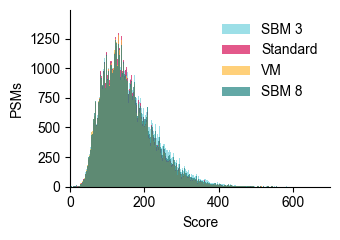

In [57]:
fig, ax = plt.subplots(figsize=(3.5, 2.5))

for dataset in big_df['Dataset'].unique():
    subset = big_df[big_df['Dataset'] == dataset]
    ax.hist(
        subset['Score'], 
        bins=1000, 
        alpha=0.7, 
        label=dataset,
        color=color_map.get(dataset, 'grey'),  # Default to grey if not in color_map
        edgecolor=None
    )

# Customize axes
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('Score')
ax.set_ylabel('PSMs')
ax.set_xlim(0, 700)
ax.set_title('')

# Layout & legend
plt.tight_layout()
legend = ax.legend(loc='upper right', frameon=False)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(1)
legend.get_frame().set_linewidth(0)

# Save
file_path = fig_dir + "score_dist_all.pdf"
plt.savefig(file_path, transparent=True)


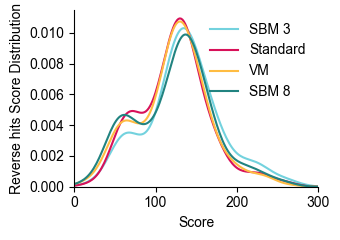

In [58]:
fig, ax = plt.subplots(figsize=(3.5, 2.5))
ax = None  # Initialize ax
for dataset in all_reverse['Dataset'].unique():
    ax = sns.kdeplot(
        data=all_reverse[all_reverse['Dataset'] == dataset], 
        x='Score', 
        color=color_map.get(dataset, 'grey'),  # Default to grey if not in color_map
        label=dataset, 
        common_norm=False, 
        fill=False
    )

if ax:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

plt.xlabel('Score')
plt.ylabel('Reverse hits Score Distribution')
plt.title('')
plt.xlim(0, 300)
plt.tight_layout()
legend = plt.legend(loc='upper right', frameon=False)
legend.get_frame().set_facecolor('white')  
legend.get_frame().set_alpha(1)
legend.get_frame().set_linewidth(0) 

file_path = fig_dir + "reverse_hit_dist.pdf"
plt.savefig(file_path, transparent=True)

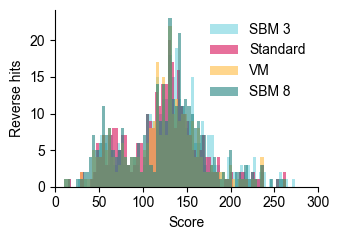

In [59]:
fig, ax = plt.subplots(figsize=(3.5, 2.5))

for dataset in all_reverse['Dataset'].unique():
    subset = all_reverse[all_reverse['Dataset'] == dataset]
    ax.hist(
        subset['Score'], 
        bins=70, 
        alpha=0.6, 
        label=dataset,
        color=color_map.get(dataset, 'grey'),  # Default to grey if not in color_map
        edgecolor=None
    )

# Customize axes
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('Score')
ax.set_ylabel('Reverse hits')
ax.set_xlim(0, 300)
ax.set_title('')

# Layout & legend
plt.tight_layout()
legend = ax.legend(loc='upper right', frameon=False)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(1)
legend.get_frame().set_linewidth(0)

# Save
file_path = fig_dir + "all_reverse_hit_dist_histogram.pdf"
plt.savefig(file_path, transparent=True)


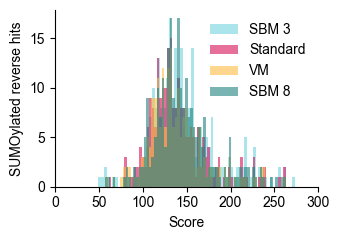

In [60]:
fig, ax = plt.subplots(figsize=(3.5, 2.5))

all_reverse_sumo = all_reverse[(all_reverse['SUMO2/3-DVFQQQTGG'] == 1)]

for dataset in all_reverse_sumo['Dataset'].unique():
    subset = all_reverse_sumo[all_reverse_sumo['Dataset'] == dataset]
    ax.hist(
        subset['Score'], 
        bins=70, 
        alpha=0.6, 
        label=dataset,
        color=color_map.get(dataset, 'grey'),  # Default to grey if not in color_map
        edgecolor=None
    )

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('Score')
ax.set_ylabel('SUMOylated reverse hits')
ax.set_xlim(0, 300)
ax.set_title('')

# Layout & legend
plt.tight_layout()
legend = ax.legend(loc='upper right', frameon=False)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(1)
legend.get_frame().set_linewidth(0)

file_path = fig_dir + "sumo_reverse_hit_dist_histogram.pdf"
plt.savefig(file_path, transparent=True)

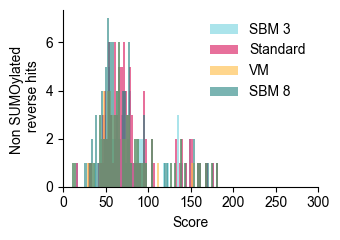

In [61]:
fig, ax = plt.subplots(figsize=(3.5, 2.5))

all_reverse_nosumo = all_reverse[(all_reverse['SUMO2/3-DVFQQQTGG'] == 0)]

for dataset in all_reverse_nosumo['Dataset'].unique():
    subset = all_reverse_nosumo[all_reverse_nosumo['Dataset'] == dataset]
    ax.hist(
        subset['Score'], 
        bins=70, 
        alpha=0.6, 
        label=dataset,
        color=color_map.get(dataset, 'grey'),  # Default to grey if not in color_map
        edgecolor=None
    )

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('Score')
ax.set_ylabel('Non SUMOylated \n reverse hits')
ax.set_xlim(0, 300)
ax.set_title('')

# Layout & legend
plt.tight_layout()
legend = ax.legend(loc='upper right', frameon=False)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(1)
legend.get_frame().set_linewidth(0)

file_path = fig_dir + "non_sumoreverse_hit_dist_histogram.pdf"
plt.savefig(file_path, transparent=True)

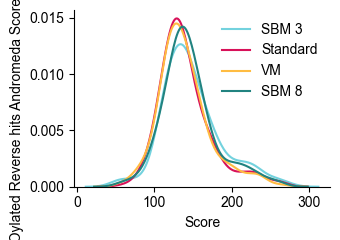

In [62]:
fig, ax = plt.subplots(figsize=(3.5, 2.5))

all_reverse_sumo = all_reverse[(all_reverse['SUMO2/3-DVFQQQTGG'] == 1)]

ax = None  # Initialize ax
for dataset in all_reverse_sumo['Dataset'].unique():
    ax = sns.kdeplot(
        data=all_reverse_sumo[all_reverse_sumo['Dataset'] == dataset], 
        x='Score', 
        color=color_map.get(dataset, 'grey'),  # Default to grey if not in color_map
        label=dataset, 
        common_norm=False, 
        fill=False
    )

if ax:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

plt.xlabel('Score')
plt.ylabel('SUMOylated Reverse hits Andromeda Score Distribution')
plt.title('')
plt.tight_layout()
legend = plt.legend(loc='upper right', frameon=True)
legend.get_frame().set_facecolor('white')  
legend.get_frame().set_alpha(1)
legend.get_frame().set_linewidth(0) 

file_path = fig_dir + "SUMO_reverse_hit_dist.pdf"
plt.savefig(file_path, transparent=True)


# Seperating data into diffrent sets

In [63]:
big_df = big_df.sort_values(by="Score", ascending=False)

df_sumo = big_df[(big_df['SUMO2/3-DVFQQQTGG'] == 1)]
df_no_sumo = big_df[(big_df['SUMO2/3-DVFQQQTGG'] == 0)] 
df_sumo_more = big_df[(big_df['SUMO2/3-DVFQQQTGG'] > 1)] 

# filtered pep 0.01
#PEP_sumo_df = df_sumo[df_sumo['PEP'] < 0.01]
#PEP05_sumo_df = df_sumo[df_sumo['PEP'] < 0.05]

# unique sites and peptides  
df_sumo_unique = df_sumo.groupby('Dataset').apply(lambda x: x.drop_duplicates(subset=['Modified sequence'], keep='first')).reset_index(drop=True)
df_unique = all_psms.groupby('Dataset').apply(lambda x: x.drop_duplicates(subset=['Modified sequence'], keep='first')).reset_index(drop=True)

all_unique_counts = df_unique.groupby('Dataset').size()

In [64]:
filtered_big_df_sumo = df_sumo[df_sumo['Reverse'] != '+']
filtered_counts = filtered_big_df_sumo.groupby('Dataset').size()

filtered_big_df_moresuno = df_sumo_more[df_sumo_more['Reverse'] != '+']
filtered_counts_moresumo = filtered_big_df_moresuno.groupby('Dataset').size()

filtered_big_df_unique = df_sumo_unique[df_sumo_unique['Reverse'] != '+']
filtered_counts_unique = filtered_big_df_unique.groupby('Dataset').size()

filtered_big_df_no_sumo = df_no_sumo[df_no_sumo['Reverse'] != '+']
filtered_counts_no_sumo = filtered_big_df_no_sumo.groupby('Dataset').size()

filtered_big_df_unique_peps = df_unique[df_unique['Reverse'] != '+']
filtered_counts_unique_peps = filtered_big_df_unique_peps.groupby('Dataset').size()

# Visualisations

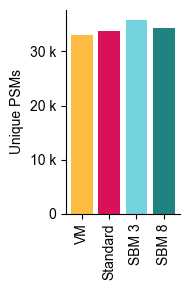

In [65]:

fig, ax = plt.subplots(figsize=(2, 3))

sorted_counts = all_unique_counts.reindex(custom_order)

#for bar in bars:
#    height = bar.get_height()
#    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

bars = ax.bar(
    sorted_counts.index,
    sorted_counts.values,
    color=[color_map.get(dataset, 'grey') for dataset in sorted_counts.index]
)

ax.set_xticks(range(len(sorted_counts.index)))
ax.set_xticklabels(sorted_counts.index, rotation=90)
ax.set_xlabel('')
ax.set_ylabel('Unique PSMs')
ax.set_title('')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
file_path = fig_dir + "nr_unique_psms.pdf"
plt.savefig(file_path, transparent=True)
plt.show() 

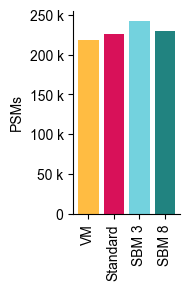

In [66]:
custom_order = [name for name in custom_order if name in all_counts.index]
ordered_counts = all_counts.reindex(custom_order)

# Create figure and axis
fig, ax_psms = plt.subplots(figsize=(2, 3))

# Bar plot with custom colors
psm_bars = ax_psms.bar(
    ordered_counts.index,
    ordered_counts.values,
    color=[color_map.get(dataset, 'grey') for dataset in ordered_counts.index]
)

ax_psms.set_xlabel('')
ax_psms.set_ylabel('PSMs')
ax_psms.set_title('')
ax_psms.set_xticks(range(len(ordered_counts.index)))
ax_psms.set_xticklabels(ordered_counts.index, rotation=90)
ax_psms.spines['right'].set_visible(False)
ax_psms.spines['top'].set_visible(False)
ax_psms.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
output_path = fig_dir + "nr_psms.pdf"
plt.savefig(output_path, transparent=True)
plt.show()

# For non SUMOylated peptides

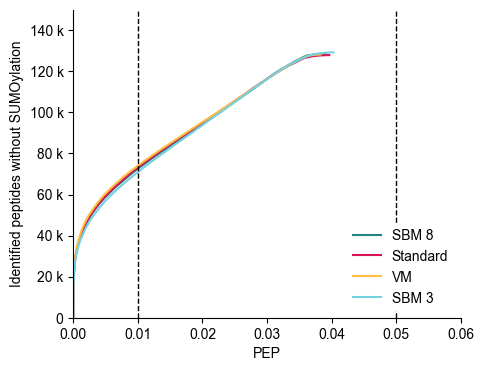

In [67]:
sorted_df = df_no_sumo.sort_values(by='PEP').reset_index(drop=True)
categories = sorted_df['Dataset'].unique() 

fig, ax = plt.subplots(figsize=(5, 4))

for group in categories:
    group_data = df_no_sumo[df_no_sumo['Dataset'] == group]
    sorted_df = group_data.sort_values(by='PEP').reset_index(drop=True)
    color = color_map.get(group, 'black')  
    ax.plot(sorted_df['PEP'], sorted_df.index, color=color, label=group)

ax.axvline(x=0.01, color='black', linestyle='--', linewidth=1)
ax.axvline(x=0.05, color='black', linestyle='--', linewidth=1)
ax.set_xlim(0, 0.06)
ax.set_ylim(0, 150000)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
ax.legend(title='Search')
ax.set_title('')
ax.set_ylabel('Identified peptides without SUMOylation')
ax.set_xlabel('PEP')

legend = plt.legend(loc='lower right', frameon=True)
legend.get_frame().set_facecolor('white')  
legend.get_frame().set_alpha(1)
legend.get_frame().set_linewidth(0) 

file_path = fig_dir + "sumo_unmodified_peptides_curve.pdf"
plt.savefig(file_path, transparent=True)

plt.show()

/Users/hmt128/miniconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/Users/hmt128/miniconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/4078850880.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


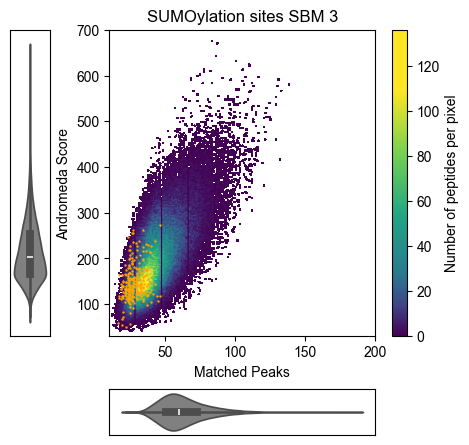

/Users/hmt128/miniconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/Users/hmt128/miniconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/4078850880.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


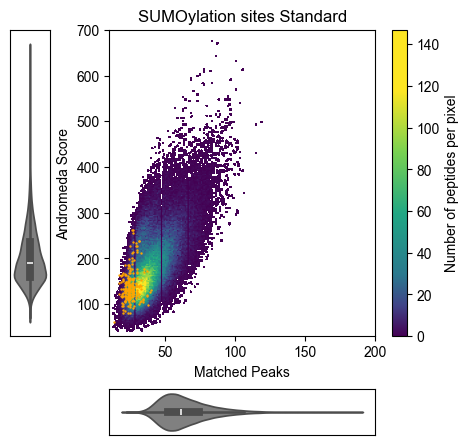

/Users/hmt128/miniconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/Users/hmt128/miniconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/4078850880.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


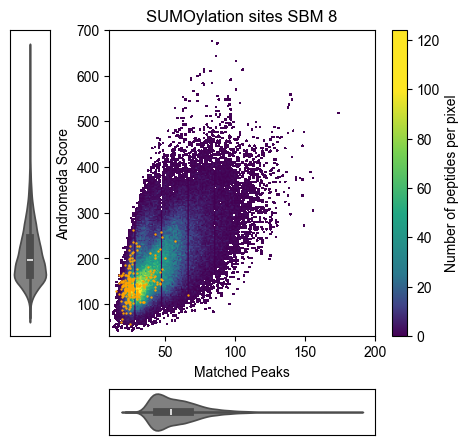

/Users/hmt128/miniconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/Users/hmt128/miniconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/4078850880.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


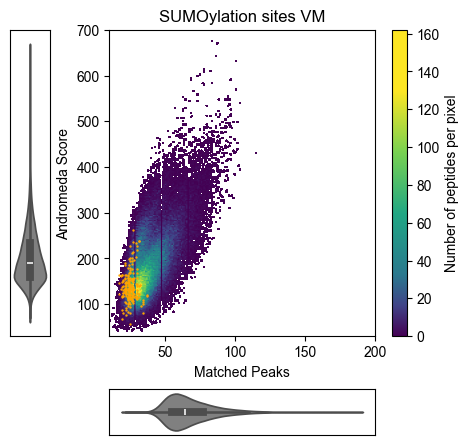

In [68]:
num_levels = 50000

white_viridis = LinearSegmentedColormap.from_list('white_viridis', [
    (0, '#ffffff'),
    (1e-20, '#440053'),
    (0.1, '#404388'),
    (0.2, '#2a788e'),
    (0.4, '#21a784'),
    (0.6, '#78d151'),
    (0.8, '#fde624'),
    (1, '#fde624'),
], N=num_levels)

def using_mpl_scatter_density(fig, x, y, color, filename=None, title=None, dpi=72):
    fig = plt.figure(figsize=(4.5, 4))  # Increase figure size to fit boxplots
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
    
    # Scatter density plot
    density = ax.scatter_density(x[color == 'default'], y[color == 'default'], cmap=white_viridis)
    # Colorbar
    #cax = fig.add_axes([0.85, 0.2, 0.03, 0.6])  # [left, bottom, width, height]
    #fig.colorbar(density, cax=cax, label='Number of peptides per pixel')
    fig.colorbar(density, label='Number of peptides per pixel', ax=ax)  
    ax.scatter(x[color == 'orange'], y[color == 'orange'], color='orange', s=0.5, alpha=1, label='Reverse')
    
    # Labels and limits
    ax.set_xlabel('Matched Peaks')
    ax.set_ylabel('Andromeda Score')
    ax.set_xlim(10, 200) 
    ax.set_ylim(30, 700)
    
    if title:
        ax.set_title(title)
    
    ax_xbox = inset_axes(ax, width="100%", height="15%", loc='upper center', bbox_to_anchor=(0, -1.15, 1, 1), bbox_transform=ax.transAxes)
    sns.violinplot(x=x, ax=ax_xbox, color='gray')
    ax_xbox.set_xticks([])
    ax_xbox.set_yticks([])
    ax_xbox.set_xlabel('')
    ax_xbox.set_ylabel('')
    
    # Add boxplot for y-axis
    ax_ybox = inset_axes(ax, width="15%", height="100%", loc='center left', bbox_to_anchor=(-0.4, 0, 1, 1), bbox_transform=ax.transAxes)
    sns.violinplot(y=y, ax=ax_ybox, color='gray', orient='v')
    ax_ybox.set_xticks([])
    ax_ybox.set_yticks([])
    ax_ybox.set_xlabel('')
    ax_ybox.set_ylabel('')

    plt.tight_layout()
    plt.legend(frameon=False, loc='lower right')

    if filename: 
        plt.savefig(filename, bbox_inches='tight', dpi=dpi, transparent=True) # 
    
    plt.show()

group_column = 'Dataset'

for category in df_sumo[group_column].unique():
    category_df = df_sumo[df_sumo[group_column] == category]
    
    x = category_df['Number of matches'].values
    y = category_df['Score'].values
    reverse_flag = category_df['Reverse'].values
    
    color = np.where(reverse_flag == '+', 'orange', 'default')

    output_file = os.path.join(fig_dir, f"scatter_density_{category}.pdf")

    using_mpl_scatter_density(fig, x, y, color, output_file, f"SUMOylation sites {category}")


# For SUMOylated peptides

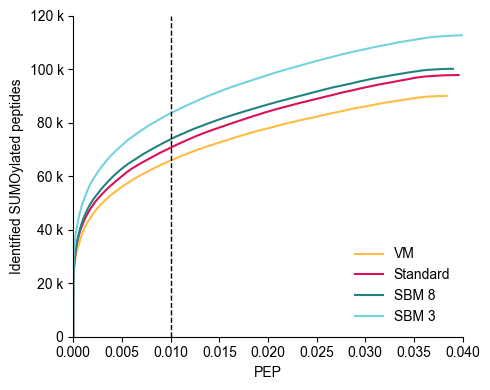

In [69]:
sorted_df = df_sumo.sort_values(by='PEP').reset_index(drop=True)
categories = sorted_df['Dataset'].unique() 

fig, ax = plt.subplots(figsize=(5, 4))

for group in categories:
    group_data = df_sumo[df_sumo['Dataset'] == group]
    sorted_df = group_data.sort_values(by='PEP').reset_index(drop=True)
    color = color_map.get(group, 'black')  # Use color from color_map, default to black if not found
    ax.plot(sorted_df['PEP'], sorted_df.index, color=color, label=group)

ax.axvline(x=0.01, color='black', linestyle='--', linewidth=1)
ax.axvline(x=0.05, color='black', linestyle='--', linewidth=1)
ax.set_xlim(0, 0.04)
ax.set_ylim(0, 120000)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())

ax.legend(title='Search')
ax.set_title('')
ax.set_ylabel('Identified SUMOylated peptides')
ax.set_xlabel('PEP')

legend = plt.legend(loc='lower right', frameon=True)
legend.get_frame().set_facecolor('white')  # Set background to white
legend.get_frame().set_alpha(1)
legend.get_frame().set_linewidth(0) 
plt.tight_layout()

file_path = fig_dir + "pep_curve_sumoylated_peptides.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

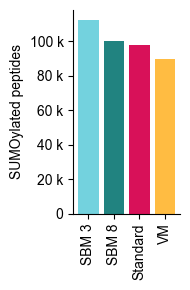

In [70]:
fig, ax = plt.subplots(figsize=(2, 3))
bars = ax.bar(filtered_counts.index, filtered_counts.values, 
    color=[color_map.get(dataset, 'grey') for dataset in filtered_counts.index]
)

#for bar in bars:
#    height = bar.get_height()
#    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax.set_xlabel('')
ax.set_ylabel('SUMOylated peptides')
ax.set_title('')
ax.set_xticks(filtered_counts.index) 
ax.set_xticklabels(filtered_counts.index, rotation=90) 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
file_path = fig_dir + "nr_sumoylated_peptides.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

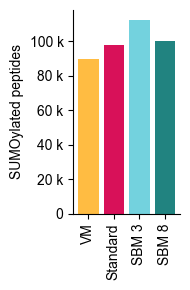

In [71]:
custom_order = [name for name in custom_order if name in filtered_counts.index]
ordered_filtered_counts = filtered_counts.reindex(custom_order)

# Create figure and axis
fig, ax_sumo = plt.subplots(figsize=(2, 3))

# Plot bars with colors from color_map
sumo_bars = ax_sumo.bar(
    ordered_filtered_counts.index,
    ordered_filtered_counts.values,
    color=[color_map.get(dataset, 'grey') for dataset in ordered_filtered_counts.index]
)

# Optional: annotate bar heights
# for bar in sumo_bars:
#     height = bar.get_height()
#     ax_sumo.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

# Set axis labels and ticks
ax_sumo.set_xlabel('')
ax_sumo.set_ylabel('SUMOylated peptides')
ax_sumo.set_title('')
ax_sumo.set_xticks(range(len(ordered_filtered_counts.index)))
ax_sumo.set_xticklabels(ordered_filtered_counts.index, rotation=90)

# Remove top/right spines
ax_sumo.spines['right'].set_visible(False)
ax_sumo.spines['top'].set_visible(False)
ax_sumo.yaxis.set_major_formatter(ticker.EngFormatter())

plt.tight_layout()
output_path = fig_dir + "nr_sumoylated_peptides.pdf"
plt.savefig(output_path, transparent=True)
plt.show()

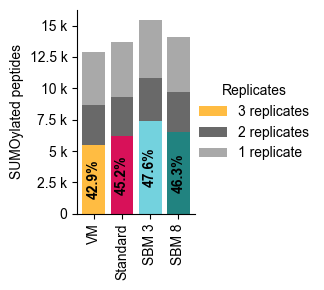

In [72]:
df_sumo_filtered = df_sumo[df_sumo['Dataset'].isin(custom_order)]
df_sumo_filtered['Dataset'] = pd.Categorical(df_sumo_filtered['Dataset'], categories=custom_order, ordered=True)
df_sumo_filtered = df_sumo_filtered.sort_values('Dataset')

grey_shades = ['#D3D3D3', '#A9A9A9', '#696969']
fig, ax_completeness = plt.subplots(figsize=(4.5, 3))
dataset_positions = np.arange(len(custom_order))

bar_width = 0.8

for i, dataset in enumerate(custom_order):
    data = df_sumo_filtered[df_sumo_filtered['Dataset'] == dataset]
    replicate_counts = data.groupby('Modified sequence')['R'].nunique()
    replicate_distribution = replicate_counts.value_counts().reindex([1, 2, 3], fill_value=0)
    bottom = 0
    total_sequences = replicate_distribution.sum()
    color_3_replicates = color_map.get(dataset, 'grey')

    if replicate_distribution[3] > 0:
        ax_completeness.bar(dataset_positions[i], replicate_distribution[3], color=color_3_replicates, bottom=bottom, width=bar_width, edgecolor=None)
        ax_completeness.text(dataset_positions[i], bottom + replicate_distribution[3] / 2, f'{(replicate_distribution[3] / total_sequences) * 100:.1f}%',
                             ha='center', va='center', fontsize=10, color='black', fontweight='bold', rotation=90)
        bottom += replicate_distribution[3]

    if replicate_distribution[2] > 0:
        ax_completeness.bar(dataset_positions[i], replicate_distribution[2], color=grey_shades[2], bottom=bottom, width=bar_width, edgecolor=None)
        bottom += replicate_distribution[2]

    if replicate_distribution[1] > 0:
        ax_completeness.bar(dataset_positions[i], replicate_distribution[1], color=grey_shades[1], bottom=bottom, width=bar_width, edgecolor=None)
        bottom += replicate_distribution[1]

ax_completeness.set_xticks(dataset_positions)
ax_completeness.set_xticklabels(custom_order, rotation=90)
ax_completeness.yaxis.set_major_formatter(ticker.EngFormatter())
ax_completeness.set_xlabel("")
ax_completeness.set_ylabel("SUMOylated peptides")
ax_completeness.spines['top'].set_visible(False)
ax_completeness.spines['right'].set_visible(False)
ax_completeness.legend(
    ['3 replicates', '2 replicates', '1 replicate'],
    loc="upper center",
    title="Replicates",
    frameon=False,
    bbox_to_anchor=(1.5, 0.7)
)

plt.tight_layout()
output_path = fig_dir + "data_completeness.pdf"
plt.savefig(output_path, transparent=True)
plt.show()


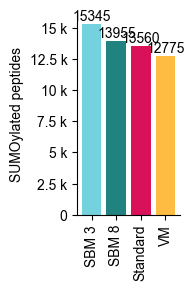

In [73]:
fig, ax = plt.subplots(figsize=(2, 3))
bars_un = ax.bar(
    filtered_counts_unique.index, 
    filtered_counts_unique.values, 
    color=[color_map.get(dataset, 'grey') for dataset in filtered_counts_unique.index]
)

for bar in bars_un:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax.set_xlabel('')
ax.set_ylabel('SUMOylated peptides')
ax.set_title('')
ax.set_xticks(filtered_counts_unique.index) 
#ax.set_ylim(0, 9000)
ax.set_xticklabels(filtered_counts_unique.index, rotation=90) # rotation=45,  
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()

file_path = fig_dir + "unique_sumo_peptides.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/989690403.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_violin.set_xticklabels(custom_order, rotation=90)


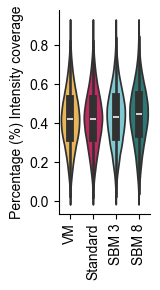

In [87]:
combined_data_int = filtered_big_df_sumo.pivot(columns='Dataset', values='Intensity coverage')
combined_data_int = combined_data_int[custom_order]

fig, ax_violin = plt.subplots(figsize=(1.7, 3))
sns.violinplot(data=combined_data_int, ax=ax_violin, palette=[color_map[ds] for ds in custom_order])
ax_violin.set_title('')
ax_violin.set_xlabel('')
ax_violin.set_ylabel('Percentage (%) Intensity coverage')
ax_violin.spines['right'].set_visible(False)
ax_violin.spines['top'].set_visible(False)
ax_violin.set_xticklabels(custom_order, rotation=90)

plt.tight_layout()
output_path = fig_dir + "intensity_coverage.pdf"
plt.savefig(output_path, transparent=True)
plt.show()

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/1089731511.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_violin_peak.set_xticklabels(custom_order, rotation=90)


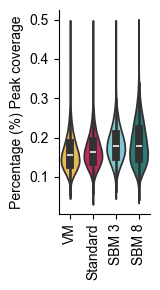

In [88]:
combined_data_peak = filtered_big_df_sumo.pivot(columns='Dataset', values='Peak coverage')
combined_data_peak = combined_data_peak[custom_order]

fig, ax_violin_peak = plt.subplots(figsize=(1.7, 3))
sns.violinplot(data=combined_data_peak, ax=ax_violin_peak, palette=[color_map[ds] for ds in custom_order])
ax_violin_peak.set_title('')
ax_violin_peak.set_xlabel('')
ax_violin_peak.set_ylabel('Percentage (%) Peak coverage')
ax_violin_peak.spines['right'].set_visible(False)
ax_violin_peak.spines['top'].set_visible(False)
ax_violin_peak.set_xticklabels(custom_order, rotation=90)

plt.tight_layout()
output_path = fig_dir + "peak_coverage.pdf"
plt.savefig(output_path, transparent=True)
plt.show()

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/3533426722.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_violin_peak.set_xticklabels(custom_order, rotation=90)


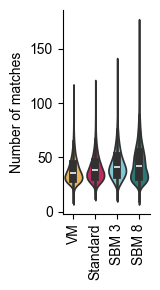

In [89]:
combined_data_peak = filtered_big_df_sumo.pivot(columns='Dataset', values='Number of matches')
combined_data_peak = combined_data_peak[custom_order]

fig, ax_violin_peak = plt.subplots(figsize=(1.7, 3))
sns.violinplot(data=combined_data_peak, ax=ax_violin_peak, palette=[color_map[ds] for ds in custom_order])
ax_violin_peak.set_title('')
ax_violin_peak.set_xlabel('')
ax_violin_peak.set_ylabel('Number of matches')
ax_violin_peak.spines['right'].set_visible(False)
ax_violin_peak.spines['top'].set_visible(False)
ax_violin_peak.set_xticklabels(custom_order, rotation=90)

plt.tight_layout()
output_path = fig_dir + "Nr_matches.pdf"
plt.savefig(output_path, transparent=True)
plt.show()

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/778616161.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values_by_dataset.index, y=missing_values_by_dataset.values, ax=ax_missing,
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/778616161.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_missing.set_xticklabels(custom_order, rotation=90)


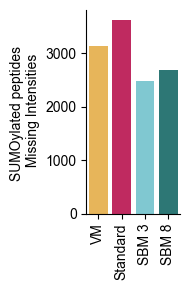

In [77]:
missing_values_by_dataset = filtered_big_df_sumo.groupby('Dataset')['Intensity'].apply(lambda x: x.isna().sum())
missing_values_by_dataset = missing_values_by_dataset[custom_order]

fig, ax_missing = plt.subplots(figsize=(2, 3))
sns.barplot(x=missing_values_by_dataset.index, y=missing_values_by_dataset.values, ax=ax_missing, 
            palette=[color_map[ds] for ds in custom_order])

ax_missing.set_xlabel('')
ax_missing.set_ylabel('SUMOylated peptides \n Missing Intensities')
ax_missing.set_title('')
ax_missing.spines['right'].set_visible(False)
ax_missing.spines['top'].set_visible(False)
ax_missing.set_xticklabels(custom_order, rotation=90)

plt.tight_layout()
output_path = fig_dir + "missing_values_sumosites.pdf"
plt.savefig(output_path, transparent=True)
plt.show()

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/1260705779.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values_by_dataset.index, y=missing_values_by_dataset.values, ax=ax_missing,
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/1260705779.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_missing.set_xticklabels(custom_order, rotation=90)


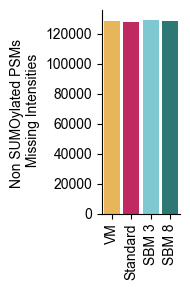

In [78]:
missing_values_by_dataset = df_no_sumo.groupby('Dataset')['Intensity'].apply(lambda x: x.isna().sum())
missing_values_by_dataset = missing_values_by_dataset[custom_order]

fig, ax_missing = plt.subplots(figsize=(2, 3))
sns.barplot(x=missing_values_by_dataset.index, y=missing_values_by_dataset.values, ax=ax_missing, 
            palette=[color_map[ds] for ds in custom_order])

ax_missing.set_xlabel('')
ax_missing.set_ylabel('Non SUMOylated PSMs \n Missing Intensities')
ax_missing.set_title('')
ax_missing.spines['right'].set_visible(False)
ax_missing.spines['top'].set_visible(False)
ax_missing.set_xticklabels(custom_order, rotation=90)

plt.tight_layout()
output_path = fig_dir + "missing_values_nonsumopeptides.pdf"
plt.savefig(output_path, transparent=True)
plt.show()

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/2227876213.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values_by_dataset.index, y=missing_values_by_dataset.values, ax=ax,
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/2227876213.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(custom_order, rotation=90)


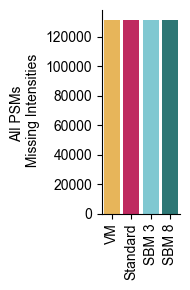

In [79]:
# Group by 'Dataset' and count missing values in 'Intensity' column
missing_values_by_dataset = all_psms.groupby('Dataset')['Intensity'].apply(lambda x: x.isna().sum())

missing_values_by_dataset = missing_values_by_dataset[custom_order]

# Plot the number of missing values per dataset
fig, ax = plt.subplots(figsize=(2, 3))  # Adjust size for readability
sns.barplot(x=missing_values_by_dataset.index, y=missing_values_by_dataset.values, ax=ax, 
            palette=[color_map[dataset] for dataset in custom_order])

# Formatting the plot
ax.set_xlabel('')
ax.set_ylabel('All PSMs \n Missing Intensities')
ax.set_title('')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xticklabels(custom_order, rotation=90)

# Show the plot
plt.tight_layout()
file_path = fig_dir + "missing_values_by_dataset.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

In [82]:
filtered_big_df_sumo['scan_modseq'] =  filtered_big_df_sumo['Scan number'].astype(str) + "_" + filtered_big_df_sumo['Modified sequence'] 
filtered_big_df_sumo['scan_modseq'] 

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/2858785017.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_big_df_sumo['scan_modseq'] =  filtered_big_df_sumo['Scan number'].astype(str) + "_" + filtered_big_df_sumo['Modified sequence']


90252                          15945_DQGNTAATQTEVPSLVVK(su)K
1173239                        15945_DQGNTAATQTEVPSLVVK(su)K
1620446                        15945_DQGNTAATQTEVPSLVVK(su)K
1397811                        15945_DQGNTAATQTEVPSLVVK(su)K
1397795                        15216_DQGNTAATQTEVPSLVVK(su)K
                                 ...                        
1289001    28462_PVLPTLTTSVGLPLPPTLPSLIPFIK(su)TEEPAPIPIS...
1509547    28462_PVLPTLTTSVGLPLPPTLPSLIPFIK(su)TEEPAPIPIS...
1204461    5865_DVSLPSMQGDLKTTDLSIQPPSADLK(su)VQAGQMDVKLP...
93845                       7817_DQTNVYGSAQRRK(su)MRPFEGFQRK
91330                              8738_DQK(su)RATIQFHQPQRFK
Name: scan_modseq, Length: 399503, dtype: object

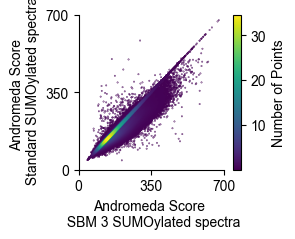

In [90]:
sbm_3_df = filtered_big_df_sumo[filtered_big_df_sumo['Dataset'] == 'SBM 3']
st_df = filtered_big_df_sumo[filtered_big_df_sumo['Dataset'] == 'Standard']
sbm_3_seqs = set(sbm_3_df["scan_modseq"])
st_seqs = set(st_df["scan_modseq"])

common_seqs = sbm_3_seqs & st_seqs

sbm_3_filtered = sbm_3_df[sbm_3_df["scan_modseq"].isin(common_seqs)]
st_filtered = st_df[st_df["scan_modseq"].isin(common_seqs)]

merged_df = sbm_3_filtered.merge(st_filtered, on="scan_modseq", suffixes=('_sbm3', '_st'))

x = merged_df["Score_sbm3"].values
y = merged_df["Score_st"].values

xy = np.vstack([x, y])
density = gaussian_kde(xy)(xy) * len(x) 

idx = density.argsort()
x, y, density = x[idx], y[idx], density[idx]
fig, ax = plt.subplots(figsize=(3, 2.5))
sc = ax.scatter(x, y, c=density, cmap='viridis', alpha=1, s=0.1)

min_val = 0
max_val = 700
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ticks = np.linspace(min_val, max_val, num=3) 
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("Andromeda Score \n SBM 3 SUMOylated spectra")
ax.set_ylabel("Andromeda Score \n Standard SUMOylated spectra")
ax.set_title("")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Number of Points") 

plt.tight_layout()
file_path = fig_dir + "mod_sec_score_sumo_peptides.pdf"
plt.savefig(file_path, format='pdf', transparent=True)
plt.show()

# Overlapping peptides 

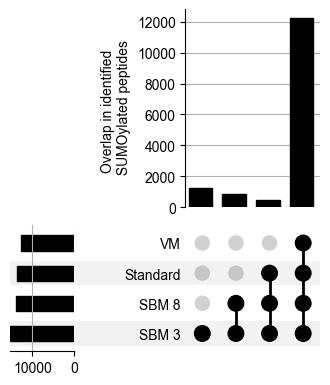

In [138]:
dataset_names = filtered_big_df_sumo['Dataset'].unique()

dataset_sequence_sets = {
    name: set(filtered_big_df_sumo[filtered_big_df_sumo['Dataset'] == name]['Modified sequence'])
    for name in dataset_names
}

all_sequences = set().union(*dataset_sequence_sets.values())

data_speps = []
for sequence in all_sequences:
    row = [sequence in sequence_set for sequence_set in dataset_sequence_sets.values()]
    row.append(sequence)
    data_speps.append(row)

column_names = list(dataset_sequence_sets.keys()) + ['Modified sequence']

df_overlap = pd.DataFrame(data_speps, columns=column_names)

df_overlap.set_index(column_names[:-1], inplace=True)

ax_dict = UpSet(df_overlap, subset_size="count", min_subset_size=300, show_counts=False).plot()
ax_dict["intersections"].set_ylabel("Overlap in identified \n SUMOylated peptides")

for bar in ax_dict['intersections'].patches:
    bar.set_width(0.7)
    bar.set_x(bar.get_x() - 0.15)
    
plt.gcf().savefig(fig_dir + "upset_plot_speps_mq.pdf", format="pdf", transparent=True)

# Identified peaks

In [92]:
def clean_string(s):
    # Remove 'SUMO-' prefix if present
    s = re.sub(r'b(\d+)-SUMO', r'd\1', s)

    if s.startswith('SUMO-'):
        s = s.replace('SUMO-', '')

    if s.endswith('(2+)'):
        s = s.replace('(2+)', '')
    
    # Remove numbers after 'y' or 'b', unless 'b' is followed by '-SUMO'
    if re.match(r'b\d+$', s):
        return 'b'

    # Remove any remaining numbers after 'y' or 'b'
    s= re.sub(r'(y|b)\d+', r'\1', s)

    if 'y*' in s:
        s = s.replace('y*', 'y-p7')
    
    # Check for 'b*' and replace with 'b-p7'
    if 'b*' in s:
        s = s.replace('b*', 'b-p7')
    
    return s

# Apply the cleaning function to each list in the column
filtered_big_df_sumo['Matches_clean'] = filtered_big_df_sumo['Matches'].apply(lambda lst: [clean_string(item) for item in lst])
df_sumo_unique['Matches_clean'] = df_sumo_unique['Matches'].apply(lambda lst: [clean_string(item) for item in lst])

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/757001483.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_big_df_sumo['Matches_clean'] = filtered_big_df_sumo['Matches'].apply(lambda lst: [clean_string(item) for item in lst])


In [93]:
#selected_df = filtered_big_df_sumo[(filtered_big_df_sumo['Dataset'] == "SBM 3") | (filtered_big_df_sumo['Dataset'] == "SBM 8") | (filtered_big_df_sumo['Dataset'] == "Standard")] 
# df_sumo_unique
selected_df = df_sumo_unique[(df_sumo_unique['Dataset'] == "SBM 3") | (df_sumo_unique['Dataset'] == "SBM 8") | (df_sumo_unique['Dataset'] == "Standard")] 

strings_to_remove = ['a2', "nan", 'y', 'b', 'y-NH3', 'y-H2O', 'b', 'b-H2O', 'b-NH3', 'd1', 'd2', 'd3', 'd4',
                     'd5' , 'd6', 'd5', 'd6', 'd7', 'd8', 'd9', 'QQ', 'FQ', 'FQQ']

def remove_strings(lst):
    return [item for item in lst if item not in strings_to_remove]

grouped = selected_df.groupby('Dataset')

category_counts = {}

for name, group in grouped:
    group['Matches_clean'] = group['Matches_clean'].apply(remove_strings)
    flattened_list = [item for sublist in group['Matches_clean'] for item in sublist]
    string_counts = Counter(flattened_list)
    category_counts[name] = string_counts

count_df = pd.DataFrame(category_counts) 

count_df = count_df.reindex(
    sorted(count_df.index, key=lambda x: int(x.split('p')[1]))
)

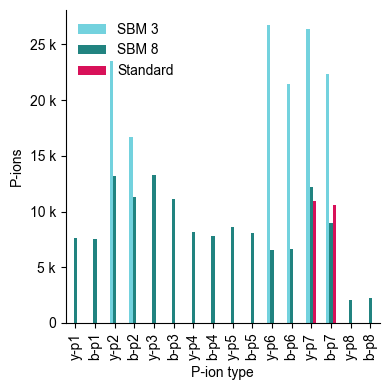

In [94]:
fig, ax = plt.subplots(figsize=(4, 4))  
colors = [color_map.get(cat, 'gray') for cat in count_df.columns]  
count_df.plot(kind='bar', stacked=False, ax=ax, color=colors)
ax.set_title('') 
ax.set_xlabel('P-ion type')
ax.set_ylabel('P-ions')
ax.yaxis.set_major_formatter(ticker.EngFormatter())
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
file_path = fig_dir + "which_matched_peaks.pdf"
plt.legend(frameon=False)
plt.savefig(file_path, transparent=True)
plt.show()

# Benchmarking 


In [103]:
df_per = pd.read_csv(per_path3, delimiter="\t")
#df_psm = df_psm[~df_psm['Protein ID'].str.contains('rev_', na=False)]
df_per_sig = df_per[df_per['posterior_error_prob'] <= 0.01]
df_per_sig_q = df_per[df_per['q-value'] <= 0.01]
#df_filtered_sumo_per = df_per_sig_q[df_per_sig_q['peptide'].str.contains(r'\[su\]', na=False)] 
df_filtered_sumo_per = df_per_sig_q[df_per_sig_q['peptide'].str.contains(r'\[su\]', na=False)] 
df_filtered_sumo_per_unique = df_filtered_sumo_per.drop_duplicates(subset=['peptide'])


In [105]:
# set to merge with  no_fdr_set

df_filtered_sumo_per_merged = df_filtered_sumo_per_unique.merge(no_fdr_set, on='PSMId', how='left')
#pg_ids_sbm3 = set([int(item) for sublist in df_filtered_sumo_per_3wmbr_merged['Protein group IDs'].str.split(';') for item in sublist])
#print(len(pg_ids_sbm3))

df_filtered_sumo_per_merged = df_filtered_sumo_per_merged[~df_filtered_sumo_per_merged['proteinIds'].str.contains('CON_', na=False)]
#df_filtered_sumo_per_merged = extract_matching_sequences(df_filtered_sumo_per_merged, max_length, 'isoform_seqs', 'matched_sequences') 
#df_filtered_sumo_per_merged = extract_matching_sequences(df_filtered_sumo_per_merged, max_length, 'AF_seq', 'matched_sequences_AF', AF = True)

df_filtered_sumo_per_merged['Positions within proteins'] = df_filtered_sumo_per_merged['Positions within proteins'].str.split(';')
df_filtered_sumo_per_merged['Positions within proteins'] = df_filtered_sumo_per_merged['Positions within proteins'].apply(
    lambda x: [int(pos) for pos in x if isinstance(x, list) and pos.strip().isdigit()] if isinstance(x, list) else []
)

In [106]:
df_filtered_sumo_per_merged['matched_sequence'] = df_filtered_sumo_per_merged['matched_sequences'].apply(lambda x: x[0] if x else None)

seqs_sbm3_per = df_filtered_sumo_per_merged["matched_sequence"]
sequences_sbm3_per = flatten_and_filter(seqs_sbm3_per)
sequences_sbm3_per = [trim_sequence(seq) for seq in sequences_sbm3_per]

set_sbm3_per = set(sequences_sbm3_per)

In [108]:
def process_psm_file(psm_file, dataset_name):
    """Reads and processes a single psm.tsv file."""
    df_psm = pd.read_csv(psm_file, delimiter="\t")
    df_psm['dataset'] = dataset_name

    df_filtered = df_psm[~df_psm['Protein ID'].str.contains('rev_', na=False)]
    #df_filtered = df_psm[df_psm['Modified Peptide'].notna()]
    
    df_filtered_sumo = df_filtered[df_filtered['Modified Peptide'].str.contains(r'\[1089\]', na=False)]
    #df_filtered_sumo = df_filtered_sumo[~df_filtered_sumo['Protein ID'].str.contains('rev_', na=False)]
    
    # Remove duplicate sumo rows
    #df_filtered_sumo = df_filtered_sumo[~df_filtered_sumo['Assigned Modifications'].str.contains(r'(K\(960\.4301\)).*\1', regex=True)]
    df_unique_msfragger_sumo = df_filtered_sumo.drop_duplicates(subset=['Modified Peptide'])
    
    # Extract modification positions
    df_filtered_sumo['pos'] = df_filtered_sumo['Assigned Modifications'].str.extract(r'(\d+)(?=K\(960\.4301\))')
    
    return df_filtered, df_filtered_sumo, df_unique_msfragger_sumo

def process_folder(folder_path):
    """Processes all psm.tsv files in a folder and combines them into a single DataFrame."""
    all_dfs = []
    all_sumos = []
    all_unique = []
    
    for root, _, files in os.walk(folder_path):
        if "psm.tsv" in files:
            dataset_name = os.path.basename(root)
            psm_path = os.path.join(root, "psm.tsv")
            print(f"Processing: {psm_path}")
            psms, sumos, unique_sumo  = process_psm_file(psm_path, dataset_name)
            all_dfs.append(psms)
            all_sumos.append(sumos)
            all_unique.append(unique_sumo)
    
    combined_df = pd.concat(all_dfs, ignore_index=True)
    combined_df_s = pd.concat(all_sumos, ignore_index=True)
    combined_df_u = pd.concat(all_unique, ignore_index=True)
    
    return combined_df, combined_df_s, combined_df_u

msfragger_psms, msfragger_sumo, msfragger_unique_sumo = process_folder(msfragger_folder_path)

Processing: /Users/hmt128/Library/CloudStorage/OneDrive-UniversityofCopenhagen/Science/Projects/Ubi_like_modifiers/identification/data/msfragger_runs/MSFragger 0nl PeptideProphet/psm.tsv


/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/4115241742.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_sumo['pos'] = df_filtered_sumo['Assigned Modifications'].str.extract(r'(\d+)(?=K\(960\.4301\))')


Processing: /Users/hmt128/Library/CloudStorage/OneDrive-UniversityofCopenhagen/Science/Projects/Ubi_like_modifiers/identification/data/msfragger_runs/MSFragger 0nl Percolator/psm.tsv


/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/4115241742.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_sumo['pos'] = df_filtered_sumo['Assigned Modifications'].str.extract(r'(\d+)(?=K\(960\.4301\))')


Processing: /Users/hmt128/Library/CloudStorage/OneDrive-UniversityofCopenhagen/Science/Projects/Ubi_like_modifiers/identification/data/msfragger_runs/MSFragger 9nl PeptideProphet/psm.tsv


...

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/4115241742.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_sumo['pos'] = df_filtered_sumo['Assigned Modifications'].str.extract(r'(\d+)(?=K\(960\.4301\))')


Processing: /Users/hmt128/Library/CloudStorage/OneDrive-UniversityofCopenhagen/Science/Projects/Ubi_like_modifiers/identification/data/msfragger_runs/MSFragger 9nl Percolator/psm.tsv


/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/4115241742.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_sumo['pos'] = df_filtered_sumo['Assigned Modifications'].str.extract(r'(\d+)(?=K\(960\.4301\))')


Processing: /Users/hmt128/Library/CloudStorage/OneDrive-UniversityofCopenhagen/Science/Projects/Ubi_like_modifiers/identification/data/msfragger_runs/MSFragger 3nl PeptideProphet/psm.tsv


/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/4115241742.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_sumo['pos'] = df_filtered_sumo['Assigned Modifications'].str.extract(r'(\d+)(?=K\(960\.4301\))')


In [109]:
msfragger_psms.columns

Index(['Spectrum', 'Spectrum File', 'Peptide', 'Modified Peptide',
       'Extended Peptide', 'Prev AA', 'Next AA', 'Peptide Length', 'Charge',
       'Retention', 'Observed Mass', 'Calibrated Observed Mass',
       'Observed M/Z', 'Calibrated Observed M/Z', 'Calculated Peptide Mass',
       'Calculated M/Z', 'Delta Mass', 'Expectation', 'Hyperscore',
       'Nextscore', 'Probability', 'Number of Enzymatic Termini',
       'Number of Missed Cleavages', 'Protein Start', 'Protein End',
       'Intensity', 'Assigned Modifications', 'Observed Modifications',
       'K:960.4301', 'K:960.4301 Best Localization', 'M:15.9949',
       'M:15.9949 Best Localization', 'n:42.0106',
       'n:42.0106 Best Localization', 'Purity', 'Is Unique', 'Protein',
       'Protein ID', 'Entry Name', 'Gene', 'Protein Description',
       'Mapped Genes', 'Mapped Proteins', 'dataset', 'Proteins_list',
       'Uniprot_cannonised', 'Gene_name', 'Gene Ontology (biological process)',
       'Gene Ontology (cellular co

In [110]:
sel_msfragger_unique_sumo = msfragger_unique_sumo[msfragger_unique_sumo['dataset'] == 'MSFragger 9nl Percolator']
sel_msfragger_sumo = msfragger_sumo[msfragger_sumo['dataset'] == 'MSFragger 9nl Percolator']
sel_msfragger_psms = msfragger_psms[msfragger_psms['dataset'] == 'MSFragger 9nl Percolator']

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/2127331271.py:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  new_counts = pd.Series()
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/2127331271.py:6: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  new_counts = new_counts.append(dataset_counts)


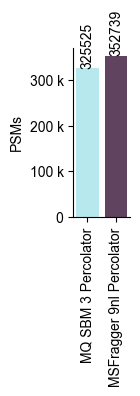

In [111]:
new_counts = pd.Series()
total_count = len(df_per_sig_q)
new_counts["MQ SBM 3 Percolator"] = total_count

dataset_counts = sel_msfragger_psms['dataset'].value_counts()
new_counts = new_counts.append(dataset_counts)

fig, ax = plt.subplots(figsize=(1.5, 4))
bars = ax.bar(new_counts.index, new_counts.values, 
    color=[color_map.get(dataset, 'grey') for dataset in new_counts.index]
)

# Optionally, add text to the bars (commented out for now)
for bar in bars:
     height = bar.get_height()
     ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom', rotation= 90)

# Customize the plot
ax.set_xlabel('')
ax.set_ylabel('PSMs')
ax.set_title('')
ax.set_xticks(new_counts.index) 
ax.set_xticklabels(new_counts.index, rotation=90) 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())

# Save and show the plot
plt.tight_layout()
file_path = fig_dir + "nr_psms_wmsfragger.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/714180542.py:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  all_counts = pd.Series()
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/714180542.py:6: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_counts = all_counts.append(dataset_counts)


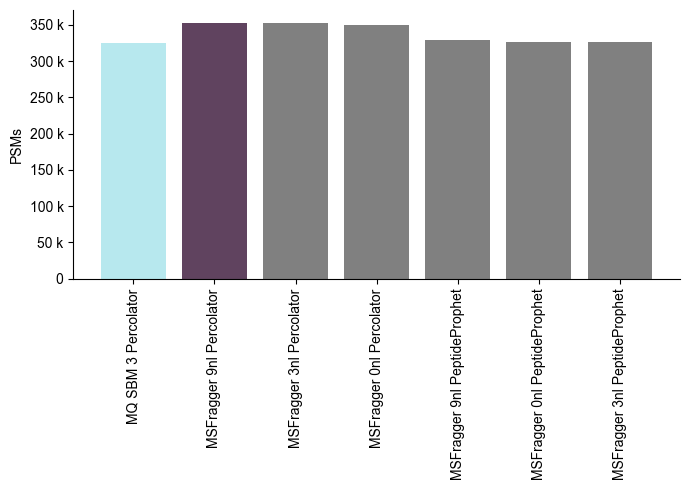

In [112]:
all_counts = pd.Series()
total_count = len(df_per_sig_q)
all_counts.loc["MQ SBM 3 Percolator"] = total_count 

dataset_counts = msfragger_psms['dataset'].value_counts()
all_counts = all_counts.append(dataset_counts)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(all_counts.index, all_counts.values, 
    color=[color_map.get(dataset, 'grey') for dataset in all_counts.index]
)

#for bar in bars:
#    height = bar.get_height()
#    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom', rotation= 90)

ax.set_xlabel('')
ax.set_ylabel('PSMs')
ax.set_title('')
ax.set_xticks(all_counts.index) 
ax.set_xticklabels(all_counts.index, rotation=90) 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
file_path = fig_dir + "nr_psms_wmsfragger.pdf"
plt.savefig(file_path, transparent=True)
plt.show() 

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/2590777065.py:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  filtered_counts = pd.Series()
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/2590777065.py:22: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  filtered_counts = filtered_counts.append(dataset_counts)


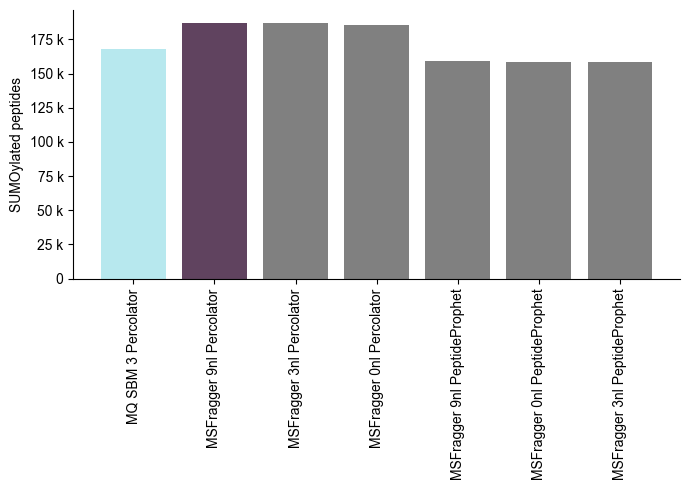

In [113]:
filtered_counts = pd.Series()

total_count = len(df_filtered_sumo_per)
filtered_counts.loc["MQ SBM 3 Percolator"] = total_count  # Add a new category called "Total" _3wmbr

#total_count_3wmbr = len(df_filtered_sumo_per_3wmbr)
#filtered_counts.loc["MQ SBM3 Percolator MBR"] = total_count_3wmbr

#total_count_3wmbr_secpep = len(df_filtered_sumo_per_3wmbr_secpep)
#filtered_counts.loc["MQ SBM3 Percolator MBR secpep"] = total_count_3wmbr_secpep

#total_count_3wsecpep = len(df_filtered_sumo_per_3wsecpep)
#filtered_counts.loc["MQ SBM3 Percolator secpep"] = total_count_3wsecpep

#total_count8 = len(df_filtered_sumo_per8)
#filtered_counts.loc["MQ SBM8 Percolator"] = total_count8 

#total_countst = len(df_filtered_sumo_perst)
#filtered_counts.loc["MQ SBMst Percolator"] = total_countst 

dataset_counts = msfragger_sumo['dataset'].value_counts()
filtered_counts = filtered_counts.append(dataset_counts)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(filtered_counts.index, filtered_counts.values, 
    color=[color_map.get(dataset, 'grey') for dataset in filtered_counts.index]
)

#for bar in bars:
#    height = bar.get_height()
#    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom', rotation=90)

ax.set_xlabel('')
ax.set_ylabel('SUMOylated peptides')
ax.set_title('')
ax.set_xticks(filtered_counts.index) 
ax.set_xticklabels(filtered_counts.index, rotation=90) 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
file_path = fig_dir + "nr_sumoylated_peptides_w_msfragger.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/2096604028.py:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  filtered_counts_unique = pd.Series()
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/2096604028.py:7: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  filtered_counts_unique = filtered_counts_unique.append(dataset_counts)


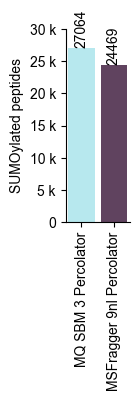

In [114]:
filtered_counts_unique = pd.Series()

total_count = len(df_filtered_sumo_per_unique)
filtered_counts_unique.loc["MQ SBM 3 Percolator"] = total_count # _3wmbr

dataset_counts = sel_msfragger_unique_sumo['dataset'].value_counts()
filtered_counts_unique = filtered_counts_unique.append(dataset_counts)

fig, ax = plt.subplots(figsize=(1.5, 4))
bars_un = ax.bar(
    filtered_counts_unique.index, 
    filtered_counts_unique.values, 
    color=[color_map.get(dataset, 'grey') for dataset in filtered_counts_unique.index]
)

for bar in bars_un:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom', rotation= 90)

ax.set_xlabel('')
ax.set_ylabel('SUMOylated peptides')
ax.set_title('')
ax.set_xticks(filtered_counts_unique.index) 
ax.set_ylim(0, 30000)
ax.set_xticklabels(filtered_counts_unique.index, rotation=90) # rotation=45,  

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()

file_path = fig_dir + "unique_sumo_peptides_w_msfragger.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/1776802413.py:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  filtered_counts_unique = pd.Series()
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/1776802413.py:6: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  filtered_counts_unique = filtered_counts_unique.append(dataset_counts)


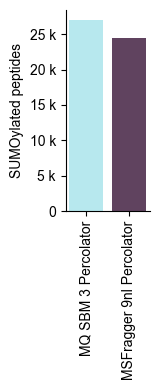

In [115]:
filtered_counts_unique = pd.Series()
total_count = len(df_filtered_sumo_per_unique)
filtered_counts_unique["MQ SBM 3 Percolator"] = total_count  

dataset_counts = sel_msfragger_unique_sumo['dataset'].value_counts()
filtered_counts_unique = filtered_counts_unique.append(dataset_counts)

fig, ax = plt.subplots(figsize=(1.7, 4))

bars_un = ax.bar(
    filtered_counts_unique.index, 
    filtered_counts_unique.values, 
    color=[color_map.get(dataset, 'grey') for dataset in filtered_counts_unique.index]
)

# Optionally, add text to the bars (commented out for now)
# for bar in bars_un:
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom', rotation= 90)

# Customize the plot
ax.set_xlabel('')
ax.set_ylabel('SUMOylated peptides')
ax.set_title('')
ax.set_xticks(filtered_counts_unique.index)
ax.set_xticklabels(filtered_counts_unique.index, rotation=90)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
file_path = fig_dir + "unique_sumo_peptides_w_msfragger.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

In [116]:
def check_sequence(row):
    seq_parts = row['Extended Peptide'].split('.')
    first_pep_len = len(seq_parts[0])
    
    if len(seq_parts) != 3:
        return None 
    
    middle_seq = seq_parts[1]
    extended_peptide = row['Extended Peptide'].replace('.', '') 

    window_size = 15
    half_window = window_size // 2

    center_pos = int(row['pos']) + first_pep_len

    start = max(center_pos - half_window, 0)
    end = min(center_pos + half_window + 1, len(extended_peptide))

    sub_peptide = extended_peptide[start:end]
    sub_length = len(sub_peptide)
    
    if sub_length < window_size:
        padding_needed = window_size - sub_length

        # Determine if we need to pad more on the left or right
        # Calculate distances from the center to the left and right of the substring
        left_padding = center_pos - start
        right_padding = end - center_pos - 1

        # If we need more padding on the left, pad to the left
        if left_padding >= right_padding:
            padded_peptide = sub_peptide.ljust(window_size, '-')
        else:
            padded_peptide = sub_peptide.rjust(window_size, '-')

    else:
        # If the substring is already 15 characters, no padding needed
        padded_peptide = sub_peptide

    if row['pos'] == row['Peptide Length']:
        print('hey')

    # Check if position is at the end of the middle sequence
    if row['pos'] == len(middle_seq):
        print('end')
        next_seq = seq_parts[2]  # The sequence after the second '.'
        if next_seq and next_seq[0] in ('D', 'E'): 
            return padded_peptide
    
    # If position is not at the end of the middle sequence
    elif row['pos'] != len(middle_seq):
        # Return the padded peptide
        return padded_peptide
    
    return None

#sel_msfragger_unique_sumo = msfragger_unique_sumo[msfragger_unique_sumo['dataset'] == 'MSFragger 9nl Percolator']
#sel_msfragger_sumo = msfragger_sumo[msfragger_sumo['dataset'] == 'MSFragger 9nl Percolator']
#sel_msfragger_psms = msfragger_psms[msfragger_psms['dataset'] == 'MSFragger 9nl Percolator']

sel_msfragger_sumo['valid_sequence'] = sel_msfragger_sumo.apply(check_sequence, axis=1)
#sel_msfragger[['valid_sequence', 'pos', 'Extended Peptide', 'Peptide', 'Peptide Length']]

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/4088356985.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sel_msfragger_sumo['valid_sequence'] = sel_msfragger_sumo.apply(check_sequence, axis=1)


In [121]:
df_filtered_sumo_per_unique['sumoylated_peptides'] = df_filtered_sumo_per_unique['peptide'].str.replace(r'.', '', regex=True).str.replace(r'\[ac\]', '', regex=True).str.replace(r'\[ox\]', '', regex=True)

sel_msfragger_u = msfragger_unique_sumo[msfragger_unique_sumo['dataset'] == 'MSFragger 9nl Percolator']
sel_msfragger_u['sumoylated_peptides'] = sel_msfragger_u['Modified Peptide'].str.replace(r'\[1089\]', '[su]', regex=True).str.replace(r'\[43\]', '', regex=True).str.replace(r'\[147\]', '', regex=True)

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/15756469.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_sumo_per_unique['sumoylated_peptides'] = df_filtered_sumo_per_unique['peptide'].str.replace(r'.', '', regex=True).str.replace(r'\[ac\]', '', regex=True).str.replace(r'\[ox\]', '', regex=True)
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_3971/15756469.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sel_msfragger_u['sumoylated_peptides'] = sel_msfragger_u['

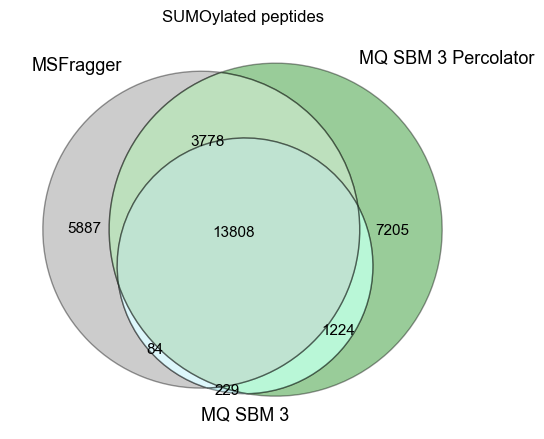

In [122]:
#st = set(filtered_big_df_unique[filtered_big_df_unique['Dataset'] == 'Standard']["Modified sequence"])

sbm3set = filtered_big_df_unique[filtered_big_df_unique['Dataset'] == 'SBM 3']["Modified sequence"].str.replace(r'\(su\)', '[su]', regex=True).str.replace(r'_', '', regex=True).str.replace(r'\(Acetyl \(Protein N-term\)\)', '', regex=True).str.replace(r'\(Oxidation \(M\)\)', '', regex=True)     # (Oxidation (M))
sbm3set_speps = set(sbm3set)
mq_speps_per = set(df_filtered_sumo_per_unique['sumoylated_peptides'])
msfragger_speps = set(sel_msfragger_u['sumoylated_peptides'])

plt.figure(figsize=(6, 6))

venn = venn3(
    [msfragger_speps, mq_speps_per, sbm3set_speps],
    ('MSFragger', 'MQ SBM 3 Percolator', 'MQ SBM 3'),
    set_colors=["grey", "green", color_map["sbm3"]]
)

for subset in venn.patches:
    if subset: 
        subset.set_edgecolor("black") 
        subset.set_linewidth(1)

for label in venn.set_labels:
    if label: 
        label.set_fontsize(13)
        
for label in venn.subset_labels:
    if label:  
        label.set_fontsize(11)

plt.title("SUMOylated peptides")
output_path = fig_dir + "overlapping_peptides_msfragger.pdf"
plt.savefig(output_path, format="pdf", transparent=True)

plt.show()

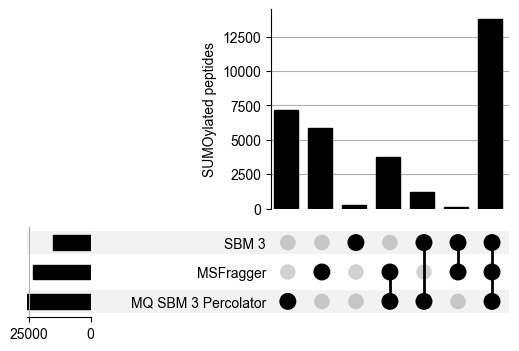

In [123]:
sbm3set_speps = set(sbm3set_speps)
mq_speps_per = set(df_filtered_sumo_per_unique['sumoylated_peptides'])
msfragger_speps = set(sel_msfragger_u['sumoylated_peptides'])

all_sequences = sbm3set_speps.union(mq_speps_per).union(msfragger_speps)
data = []

for sequence in all_sequences:
    in_sbm_3 = sequence in sbm3set_speps
    in_sbm_3_per = sequence in mq_speps_per
    in_msfrag = sequence in msfragger_speps

    data.append([in_sbm_3, in_sbm_3_per, in_msfrag, sequence])

df_overlap = pd.DataFrame(data, columns=['SBM 3', 'MQ SBM 3 Percolator', 'MSFragger', 'id'])
df_overlap.set_index(['SBM 3', 'MQ SBM 3 Percolator', 'MSFragger'], inplace=True)

ax_dict = UpSet(df_overlap, subset_size="count", min_subset_size=10, show_counts =False).plot() # , show_counts=True
ax_dict["intersections"].set_ylabel("SUMOylated peptides")

for bar in ax_dict['intersections'].patches:
    bar.set_width(0.7)  # Set to desired width (e.g., 0.8 or 1.0)
    bar.set_x(bar.get_x() - 0.15)  # Shift left so bars stay aligned (half the difference)
    
plt.gcf().savefig(fig_dir + "upset_plot_speps.pdf", format="pdf", transparent=True)

In [124]:
print(ax_dict)

{'matrix': <Axes: >, 'shading': <Axes: >, 'totals': <Axes: >, 'intersections': <Axes: ylabel='SUMOylated peptides'>}


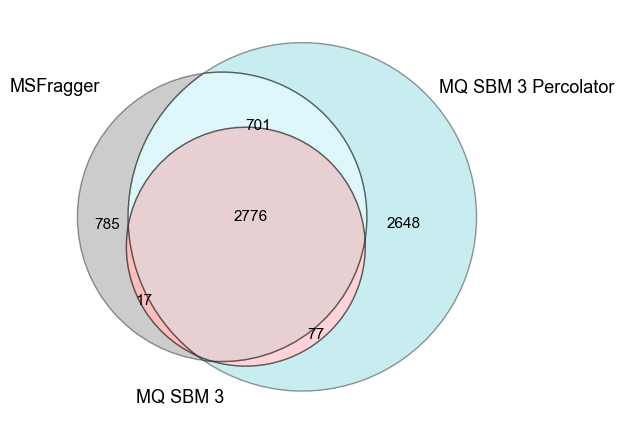

In [125]:
#mq_pg = set(list(df_sbm_3["Uniprot_cannonised"]))
sbm3set_gns = set(list(filtered_big_df_unique[filtered_big_df_unique['Dataset'] == 'SBM 3']["Gene_name_new"]))
msfragger_pg = set(list(sel_msfragger_u['Gene_name_new']))
pg_mq_per = set(list(df_filtered_sumo_per_merged['Gene_name_new']))

plt.figure(figsize=(6, 6))

venn = venn3(
    [msfragger_pg, pg_mq_per, sbm3set_gns],
    ('MSFragger', 'MQ SBM 3 Percolator', 'MQ SBM 3'),
    set_colors=['grey', color_map["sbm3"], 'red']
)

for label in venn.set_labels:
    if label: 
        label.set_fontsize(13)
        x, y = label.get_position()
        if label == venn.set_labels[0]:  
            label.set_position((x - 0.15, 0.40)) 
        elif label == venn.set_labels[1]:  
            label.set_position((x + 0.15, 0.40)) 
        elif label == venn.set_labels[2]:
            label.set_position((x + -0.2, -.50))

for label in venn.subset_labels:
    if label: 
        label.set_fontsize(11)

for subset in venn.patches:
    if subset: 
        subset.set_edgecolor("black") 
        subset.set_linewidth(1)

output_path = fig_dir + "venn_diagram_msfragger_gns.pdf"
plt.savefig(output_path, format="pdf", transparent=True)

plt.show()

In [129]:
gene_list_sbm3 = list(filtered_big_df_unique[filtered_big_df_unique['Dataset'] == 'SBM 3']["Gene_name_new"].dropna())
gene_list_msfragger = list(sel_msfragger_u["Gene_name_new"].dropna())
gene_list_maxquant = list(df_filtered_sumo_per_merged["Gene_name_new"].dropna())

df_sbm3 = pd.DataFrame({'Gene_name': gene_list_sbm3, 'Dataset': 'MQ SBM 3'})
df_msfragger = pd.DataFrame({'Gene_name': gene_list_msfragger, 'Dataset': 'MSFragger'})
df_maxquant = pd.DataFrame({'Gene_name': gene_list_maxquant, 'Dataset': 'MQ SBM 3 Percolator'})

all_genes_df = pd.concat([df_sbm3, df_msfragger, df_maxquant])

gene_counts = all_genes_df.groupby(['Dataset', 'Gene_name']).size().reset_index(name='Count')

# Step 4: Bin the counts
bins = [0, 1, 4, 9, 29, float('inf')]
labels = ['1', '3–4', '5–9', '10–29', '30+']
gene_counts['Count_Bin'] = pd.cut(gene_counts['Count'], bins=bins, labels=labels, right=True)

binned_distribution = gene_counts.groupby(['Dataset', 'Count_Bin']).size().reset_index(name='Num_Genes')

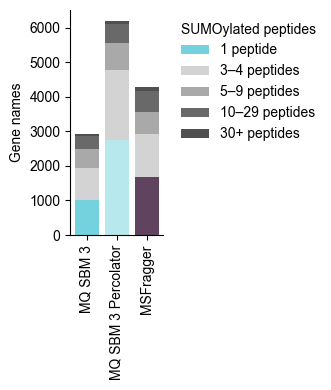

In [127]:
grey_shades = ['#D3D3D3', '#A9A9A9', '#696969', '#505050']  # For bins 3–4, 5–9, 10–29, 30+

plot_data = binned_distribution.pivot(index='Dataset', columns='Count_Bin', values='Num_Genes').fillna(0)
plot_data = plot_data[labels]  # Ensure consistent bin order

fig, ax = plt.subplots(figsize=(3.5, 4))
dataset_positions = np.arange(len(plot_data))
bar_width = 0.8

for i, dataset in enumerate(plot_data.index):
    bottom = 0
    for j, bin_label in enumerate(labels):
        height = plot_data.loc[dataset, bin_label]
        if height == 0:
            continue
        if bin_label == '1':
            color = color_map.get(dataset, 'grey')
        else:
            color = grey_shades[j - 1]  # Offset because grey_shades doesn't include '1'
        ax.bar(dataset_positions[i], height, bottom=bottom, width=bar_width, color=color, edgecolor=None)
        bottom += height

# Formatting
ax.set_xticks(dataset_positions)
ax.set_xticklabels(plot_data.index, rotation=90)
ax.set_ylabel('Gene names')
ax.set_xlabel('')
ax.set_title('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Create custom legend
from matplotlib.patches import Patch

legend_elements = [
    #Patch(facecolor=color_map.get(ds, 'grey'), label=f'{ds} \n (1 peptide)') for ds in plot_data.index # , label=f'{ds} (1 peptide)'
#] + [
    Patch(facecolor=color_map.get('MQ SBM 3'), label='1 peptide'),
    Patch(facecolor=grey_shades[0], label='3–4 peptides'),
    Patch(facecolor=grey_shades[1], label='5–9 peptides'),
    Patch(facecolor=grey_shades[2], label='10–29 peptides'),
    Patch(facecolor=grey_shades[3], label='30+ peptides')
]

ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, title='SUMOylated peptides')  

plt.tight_layout()
plt.savefig(fig_dir + "peptides_per_gnas.pdf", format="pdf", transparent=True)
plt.show()
